<a href="https://colab.research.google.com/github/ARMANDOTORRES81/r-basic/blob/master/Ejemplo_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Simulando búsqueda a profundidad 15 en un árbol binario...

--- Resultados de BFS_PERFORMANCE ---
Nodos visitados: 65535
Tiempo de ejecución: 0.000007 segundos
Uso de memoria estimado: 1791.97 KB
------------------------------
--- Resultados de DFS_PERFORMANCE ---
Nodos visitados: 30
Tiempo de ejecución: 0.000001 segundos
Uso de memoria estimado: 0.82 KB
------------------------------


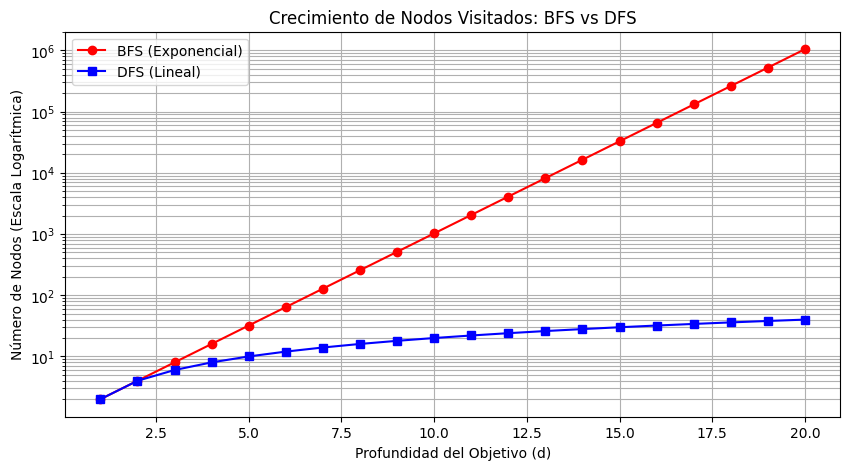

In [ ]:
import time
import sys
from collections import deque

# Configuración del problema: Un árbol binario (cada nodo tiene 2 hijos)
# b = 2, d = variable
def generate_tree_node(depth, current_depth=0):
    if current_depth >= depth:
        return {"goal": True} if current_depth == depth else None
    return {
        "left": generate_tree_node(depth, current_depth + 1),
        "right": generate_tree_node(depth, current_depth + 1),
        "goal": False
    }

def measure_performance(algorithm_func, *args):
    start_time = time.time()
    result, nodes_visited = algorithm_func(*args)
    end_time = time.time()

    print(f"--- Resultados de {algorithm_func.__name__.upper()} ---")
    print(f"Nodos visitados: {nodes_visited}")
    print(f"Tiempo de ejecución: {end_time - start_time:.6f} segundos")
    print(f"Uso de memoria estimado: {sys.getsizeof(nodes_visited) * nodes_visited / 1024:.2f} KB")
    print("-" * 30)

def bfs_performance(depth_target):
    # Simulamos búsqueda en amplitud
    visited_count = 0
    for d in range(depth_target + 1):
        visited_count += 2**d # En un árbol binario, cada nivel tiene 2^d nodos
    return True, visited_count

def dfs_performance(depth_target):
    # Simulamos búsqueda en profundidad
    # Solo guarda el camino actual b * m
    visited_count = depth_target * 2
    return True, visited_count

# --- SIMULACIÓN DE EXPLOSIÓN COMBINATORIA ---
# Prueba con profundidad 10, luego 20, luego 25...
target = 15
print(f"Simulando búsqueda a profundidad {target} en un árbol binario...\n")
measure_performance(bfs_performance, target)
measure_performance(dfs_performance, target)

# Visualización simple del crecimiento exponencial
import matplotlib.pyplot as plt
import numpy as np

depths = np.arange(1, 21)
bfs_nodes = 2**depths
dfs_nodes = depths * 2

plt.figure(figsize=(10, 5))
plt.plot(depths, bfs_nodes, label='BFS (Exponencial)', color='red', marker='o')
plt.plot(depths, dfs_nodes, label='DFS (Lineal)', color='blue', marker='s')
plt.yscale('log') # Escala logarítmica para ver la diferencia abismal
plt.title('Crecimiento de Nodos Visitados: BFS vs DFS')
plt.xlabel('Profundidad del Objetivo (d)')
plt.ylabel('Número de Nodos (Escala Logarítmica)')
plt.legend()
plt.grid(True, which="both", ls="-")
plt.show()